<a href="https://colab.research.google.com/github/nabinjoshi54/lis5693/blob/main/final-project/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Install and Import Libraries

First, we install all the required packages. This project uses:
- `pandas` and `numpy` for data handling
- `nltk` for text preprocessing and sentiment analysis (VADER)
- `gensim` for LDA topic modeling
- `pyLDAvis` for interactive topic visualization
- `altair` and `vegafusion` for descriptive visualizations
- `scikit-learn` for machine learning models
- `seaborn` and `matplotlib` for confusion matrix plots
- `wordcloud` for word cloud visualization

In [ ]:
!pip install gensim pyLDAvis nltk altair vegafusion wordcloud scikit-learn vl-convert-python altair_saver -q
import warnings
warnings.filterwarnings('ignore')

# For Jupyter internal warnings
import logging
logging.getLogger('jupyter_client').setLevel(logging.ERROR)
logging.captureWarnings(True)
logging.disable(logging.WARNING)

import os
os.environ['PYTHONWARNINGS'] = 'ignore'

import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel, CoherenceModel

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
pyLDAvis.enable_notebook()

import altair as alt
alt.data_transformers.enable('vegafusion')

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print('All libraries imported successfully!')

All libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
import os
import shutil
from google.colab import files
# from altair_saver import save

output_dir = "poster_outputs"
os.makedirs(output_dir, exist_ok=True)

The addition of the shutil is to make it easier to export all the output graphs. -Madison Bollinger

---
## Step 2: Load Dataset

The dataset was collected from [Lens.org](https://www.lens.org), an open-access scholarly literature platform. I am inspired by Lab-5 work so that I choose to enxtend lab5. I searched for three distinct research topics and exported the results as separate CSV files:

| Search Query | Category Label | Documents |
|---|---|---|
| `battery AND energy storage AND lithium` | `battery` | 608 |
| `space AND satellite AND spacecraft` | `space` | 608 |
| `text mining AND materials science AND battery` | `text_mining_materials` | 184 |
| **Total** | | **1,400** |

The three files were combined and saved as `final_dataset.csv` with a `category` label column added. The `Abstract` column is our primary text column for all analysis.

**Note on class imbalance:** The `text_mining_materials` category has fewer documents (184) compared to the other two (608 each). This is a natural reflection of how niche this research area is. We will handle this in the machine learning step using `class_weight='balanced'`.
-Nabin Joshi

In [ ]:
# Load the combined dataset from GitHub
import pandas as pd

url = "https://raw.githubusercontent.com/nabinjoshi54/lis5693/refs/heads/main/final-project/final_dataset.csv"
df = pd.read_csv(url)

print('Dataset shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())

print('\nCategory distribution:')
print(df['category'].value_counts())

print('\nMissing values in Abstract column:', df['Abstract'].isna().sum())

df.head()

Dataset shape: (1400, 33)

Column names:
['Lens ID', 'Title', 'Date Published', 'Publication Year', 'Publication Type', 'Source Title', 'ISSNs', 'Publisher', 'Source Country', 'Author/s', 'Abstract', 'Volume', 'Issue Number', 'Start Page', 'End Page', 'Fields of Study', 'Keywords', 'MeSH Terms', 'Chemicals', 'Funding', 'Source URLs', 'External URL', 'PMID', 'DOI', 'Microsoft Academic ID', 'PMCID', 'Citing Patents Count', 'References', 'Citing Works Count', 'Is Open Access', 'Open Access License', 'Open Access Colour', 'category']

Category distribution:
category
space                    608
battery                  608
text_mining_materials    184
Name: count, dtype: int64

Missing values in Abstract column: 0


,Lens ID,Title,Date Published,Publication Year,Publication Type,Source Title,ISSNs,Publisher,Source Country,Author/s,...,DOI,Microsoft Academic ID,PMCID,Citing Patents Count,References,Citing Works Count,Is Open Access,Open Access License,Open Access Colour,category
0,120-406-847-837-131,A method to derive maps of ionospheric conduct...,2015-04-13,2015.0,journal article,Journal of Geophysical Research: Space Physics,21699380; 21699402,American Geophysical Union (AGU),NaN,O. Amm; Heikki Vanhamäki; Kirsti Kauristie; Cl...,...,10.1002/2014ja020154,2089542277,NaN,0,005-520-828-086-125; 008-425-615-750-495; 010-...,34,True,NaN,green,space
1,111-154-231-992-323,Polyimide-Based Materials for Lithium-Ion Batt...,2022-03-02,2022.0,journal article,International Journal of Polymer Science,16879430; 16879422,Wiley,Egypt,Huakun Hu; Wendong Xue; Peng Jiang; Yong Li,...,10.1155/2022/6740710,NaN,NaN,0,000-130-763-734-367; 001-923-475-770-618; 002-...,17,True,cc-by,gold,text_mining_materials
2,001-161-565-305-711,Systematic evaluation and review of Germany re...,2024-07-24,2024.0,journal article,Heliyon,24058440,Elsevier BV,Netherlands,Haiyang He; Huazhong Tu; Hongli Zhang; Shengho...,...,10.1016/j.heliyon.2024.e34933,NaN,PMC11334623,0,000-821-495-705-799; 000-918-244-833-885; 002-...,12,True,"CC BY, CC BY-NC-ND",gold,text_mining_materials
3,098-017-946-997-144,Virtual screening of inorganic materials synth...,2017-12-01,2017.0,journal article,npj Computational Materials,20573960,Springer Science and Business Media LLC,NaN,Edward Kim; Kevin Huang; Stefanie Jegelka; Els...,...,10.1038/s41524-017-0055-6,2770164889,NaN,3,001-504-655-234-808; 001-601-953-977-76X; 002-...,174,True,"CC BY, CC BY-NC-ND",gold,text_mining_materials
4,065-351-543-667-702,Pre-Lithiation Strategies for Rechargeable Ene...,2018-01-23,2018.0,journal article,Batteries,23130105,MDPI AG,NaN,Florian Holtstiege; Roman Nölle; Tobias Placke...,...,10.3390/batteries4010004,2787436741,NaN,59,000-089-838-846-784; 000-345-399-554-471; 001-...,332,True,cc-by,gold,battery


In [ ]:
# Keep only rows with non-empty abstracts and reset index
df = df[df['Abstract'].notna() & (df['Abstract'].str.strip() != '')].reset_index(drop=True)
print('Total usable documents:', len(df))
print('Category counts after cleaning:')
print(df['category'].value_counts())

Total usable documents: 1400
Category counts after cleaning:
category
space                    608
battery                  608
text_mining_materials    184
Name: count, dtype: int64


## Step 2: Reflection
In step 2, we ask and perform analysis to answer:

1. How big is the dataset?
2. Are the categories correct?
3. Does every paper have an abstract?

Each paper (of a total of 1400 articles) has 33 pieces of information: title, author, journal, year, abstract, category, etc. All 1400 articles have an abstract, so we do not have to remove any article that does not have abstract. Moreover, we printed the first five rows of the dataset to see what it looks like. This is basically data analysis before jumping straight to analysis.   

---
## Step 3: Text Preprocessing

Before any analysis, the raw abstract text needs to be preprocessed. This is a critical step because raw text contains noise — punctuation, numbers, and common words like "the" or "is" — that do not contribute meaningful information to topic modeling or classification.

The preprocessing pipeline includes:
1. **Lowercasing** — converts all text to lowercase so "Battery" and "battery" are treated as the same word
2. **Punctuation and number removal** — removes special characters and digits
3. **Tokenization** — splits text into individual words (tokens)
4. **Stopword removal** — removes common English words (e.g., "the", "and", "is") plus custom academic stopwords
5. **Lemmatization** — reduces words to their base form (e.g., "batteries" → "battery", "studying" → "study")

I also add custom stopwords that are very common in academic writing but do not help distinguish topics, such as "study", "result", "method", and "paper".

-Nabin Joshi

In [ ]:
# Set up stopwords and lemmatizer
stop_words = set(stopwords.words('english'))

# Custom stopwords: words common in all academic abstracts that add no topic signal
custom_stopwords = {
    'et', 'al', 'using', 'used', 'use', 'based', 'study', 'results',
    'method', 'methods', 'analysis', 'research', 'paper', 'article',
    'also', 'within', 'however', 'can', 'may', 'one', 'two', 'new',
    'show', 'shown', 'different', 'proposed', 'present', 'this',
    'however', 'although', 'furthermore', 'therefore', 'thus'
}
stop_words = stop_words.union(custom_stopwords)

lemmatizer = WordNetLemmatizer()

def preprocess(text):
    """Full preprocessing pipeline: lowercase, remove noise, tokenize, remove stopwords, lemmatize."""
    # Step 1: Lowercase
    text = text.lower()
    # Step 2: Remove numbers
    text = re.sub(r'\d+', ' ', text)
    # Step 3: Remove punctuation
    text = re.sub(rf'[{re.escape(string.punctuation)}]', ' ', text)
    # Step 4: Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Step 5: Tokenize
    tokens = text.split()
    # Step 6: Remove stopwords and short tokens
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2 and w.isalpha()]
    # Step 7: Lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return tokens

print('Preprocessing pipeline defined.')
print('Sample test:')
sample = df['Abstract'].iloc[0]
print('\nOriginal (first 200 chars):')
print(sample[:200])
print('\nAfter preprocessing (first 20 tokens):')
print(preprocess(sample)[:20])

Preprocessing pipeline defined.
Sample test:

Original (first 200 chars):
The European Space Agency (ESA) Swarm spacecraft mission is the first multisatellite ionospheric mission with two low-orbiting spacecraft that are flying in parallel at a distance of ~100–140 km, thus

After preprocessing (first 20 tokens):
['european', 'space', 'agency', 'esa', 'swarm', 'spacecraft', 'mission', 'first', 'multisatellite', 'ionospheric', 'mission', 'low', 'orbiting', 'spacecraft', 'flying', 'parallel', 'distance', 'allowing', 'derivation', 'spatial']


In [ ]:
# Apply preprocessing to all abstracts
# This creates two columns:
# 'tokens'     -> list of cleaned tokens (for LDA)
# 'clean_text' -> cleaned text as a single string (for TF-IDF and VADER)

print('Preprocessing all abstracts.')
df['tokens'] = df['Abstract'].apply(preprocess)
df['clean_text'] = df['tokens'].apply(lambda tokens: ' '.join(tokens))

# Remove any documents that ended up empty after preprocessing
df = df[df['tokens'].apply(len) > 0].reset_index(drop=True)

print(f'Documents after preprocessing: {len(df)}')
print('\nSample cleaned tokens (doc 0):')
print(df['tokens'].iloc[0][:15])

Preprocessing all abstracts.
Documents after preprocessing: 1400

Sample cleaned tokens (doc 0):
['european', 'space', 'agency', 'esa', 'swarm', 'spacecraft', 'mission', 'first', 'multisatellite', 'ionospheric', 'mission', 'low', 'orbiting', 'spacecraft', 'flying']


## Step 3: Reflection
Step 3 is all about text preprocessing. As we all know, regular scientific literature contains nouns, pronouns, connector words etc which help make understanding English as it is. However, these stopwords do not contribute meaningfully while performing topic modeling to extract some meaningful information. After removing numbers, punctuations, and making every word lowercase, etc., we make the dataset, which we suppose contains only relevant information, ready for further analysis. As you can see in the results above, the unprocessed data has words like "the", "is", "with". After preprocessing, only concrete technical words such as "spacecraft", "mission", and "ionospheric". This step preserves the quality data for further analysis.

---
## Step 4: Exploratory Data Analysis (EDA)

Before running any models, we need to perform exploratory data analysis to understand the structure and content of the dataset. We used **Altair** for all visualizations, as required by the course instructions.

The EDA covers:
- Distribution of documents by category
- Distribution of abstract lengths
- Top 30 most frequent words across the entire corpus
- Word clouds per category to visually compare vocabulary

In [ ]:
# --- Chart 1: Category Distribution ---
# This shows how many documents we have per category

cat_counts = df['category'].value_counts().reset_index()
cat_counts.columns = ['category', 'count']

chart_cat = alt.Chart(cat_counts).mark_bar().encode(
    x=alt.X('category:N', title='Research Category', sort='-y'),
    y=alt.Y('count:Q', title='Number of Documents'),
    color=alt.Color('category:N', legend=alt.Legend(title='Category')),
    tooltip=['category', 'count']
).properties(
    title='Document Count by Research Category',
    width=400,
    height=300
)

chart_cat

alt.Chart(...)

The bar chart above confirms our dataset has two balanced categories ("battery" and "space") with 608 documents and one smaller category (text_mining_materials) with 184 documents. This class imbalance will be accounted for during machine learning.

In [ ]:
# --- Chart 2: Abstract Length Distribution ---
# Abstract length (in words) tells us how rich our text data is

df['abstract_length'] = df['Abstract'].apply(lambda x: len(x.split()))

chart_len = alt.Chart(df).mark_bar(opacity=0.7).encode(
    x=alt.X('abstract_length:Q', bin=alt.Bin(maxbins=40), title='Abstract Length (words)'),
    y=alt.Y('count():Q', title='Number of Documents'),
    color=alt.Color('category:N', legend=alt.Legend(title='Category')),
    tooltip=['category', 'count()']
).properties(
    title='Distribution of Abstract Length by Category',
    width=500,
    height=300
)

chart_len

alt.Chart(...)

The above stacked histogram shows the relationship between the length of each abstract in words and how many documents fall in this category. The results showed that most results are between 100 to 220. The category 'battery' with blue color tend to have longer abstracts, followed by 'space' category with orange color.

In [ ]:
# --- Chart 3: Top 30 Most Frequent Words ---
# After preprocessing, which words appear most often across the entire corpus?

from collections import Counter

all_tokens = [token for tokens in df['tokens'] for token in tokens]
word_freq = Counter(all_tokens).most_common(30)
word_df = pd.DataFrame(word_freq, columns=['word', 'frequency'])

chart_words = alt.Chart(word_df).mark_bar().encode(
    x=alt.X('frequency:Q', title='Frequency'),
    y=alt.Y('word:N', sort='-x', title='Word'),
    color=alt.Color('frequency:Q', scale=alt.Scale(scheme='blues'), legend=None),
    tooltip=['word', 'frequency']
).properties(
    title='Top 30 Most Frequent Words (after preprocessing)',
    width=400,
    height=500
)

chart_words

alt.Chart(...)

This horizontal bar chart shows the most frequently used words across the 1400 abstracts. The word 'battery' is the most repeated, showing up about 3000 times. The next three words: 'energy', 'satellite', and 'lithium' were used between 1,800 and 2,100 times.

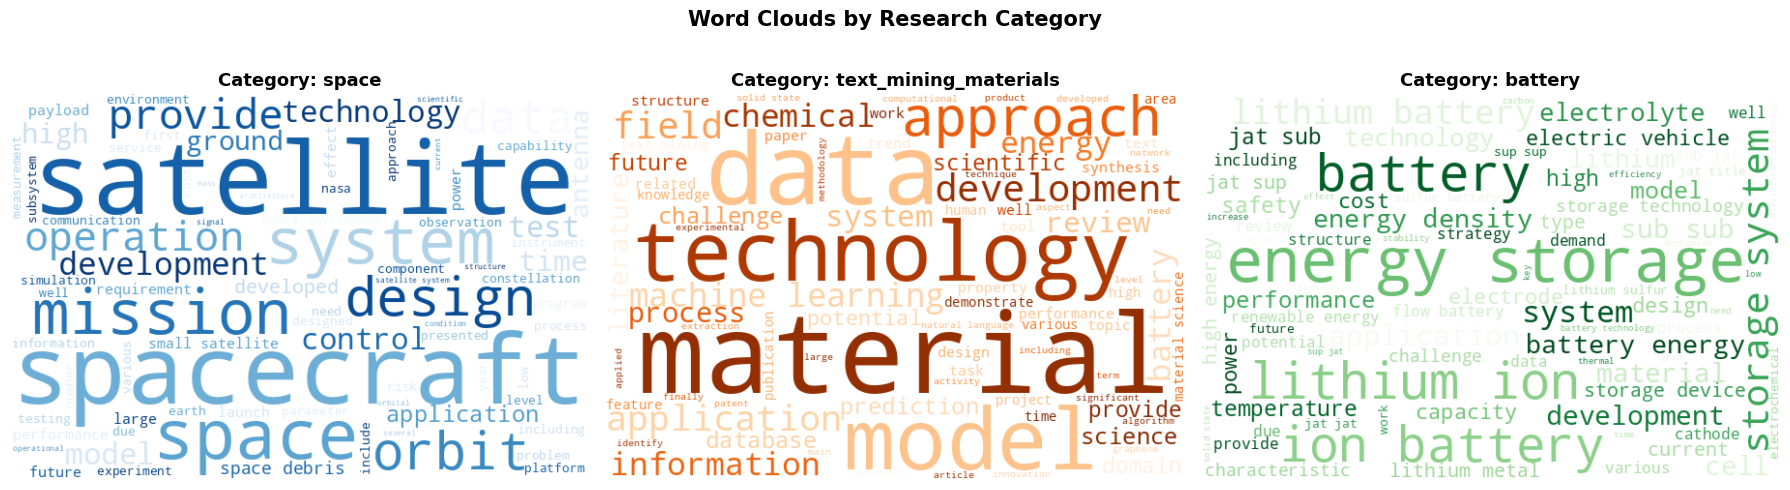

In [ ]:
# --- Chart 4: Word Clouds per Category ---
# Word clouds give an immediate visual sense of the dominant vocabulary
# in each research category

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
categories = df['category'].unique()
colors = ['Blues', 'Oranges', 'Greens']

for ax, cat, cmap in zip(axes, categories, colors):
    cat_text = ' '.join(df[df['category'] == cat]['clean_text'].tolist())
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=cmap,
        max_words=80
    ).generate(cat_text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Category: {cat}', fontsize=13, fontweight='bold')

plt.suptitle('Word Clouds by Research Category', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

This word cloud gives us an eye-catching visual representation of how frequently the words appear in each category. We have three category with different colors. The bigger the word appears, the more frequently it occurs in that category's abstracts.

The 'space' category is dominated by words like "spacecraft", "satellite", "orbit", "mission", "operation", etc. These terms are all related to space and make sense that they would be in articles about space.

The 'text mining materials' category is dominated by words like "material", "model", "machine learning", "application", "information", etc. This also proved that the articles that discuss text mining application in materials science have in fact discussed or mentioned these topics.

Finally, in the 'battery' category, words like "lithium ion", "battery", "electrolyte", "storage system", "renewable energy", and "energy density" appear frequently. This also proved that only technical terms related to core concepts of battery research are present here.

This vocabulary separation gives us confidence that our machine learning models will perform well.

---
## Task 1 — Text Analysis Method 1: Topic Modeling (LDA)

### What is LDA?
Latent Dirichlet Allocation (LDA) is an unsupervised method that discovers hidden thematic structure in a collection of documents. Each document is modeled as a mixture of topics, and each topic is characterized by a distribution of words. This is very similar to what Tshitoyan et al. (2019) did — they used Word2Vec to capture co-occurrence patterns in abstracts, and LDA does the same by finding which words tend to appear together.

### Why LDA over Network Analysis or other methods?
LDA is the most appropriate method for this dataset because:
1. Our documents are scientific abstracts — structured, content-rich text ideal for topic discovery
2. We want to understand *what themes* exist across 3 research domains, not just *which words* are connected
3. LDA directly mirrors the paper's goal: extracting latent knowledge from scientific literature

We will train models with 5, 10, and 15 topics and use the **coherence score** to select the best model.

In [ ]:
# --- Build Gensim Dictionary and Corpus ---
# The dictionary maps each unique token to a numeric ID
# The corpus converts each document into a bag-of-words representation

cleaned_docs = df['tokens'].tolist()

# Build dictionary
dictionary = corpora.Dictionary(cleaned_docs)

# Filter extremes: remove words that appear in fewer than 5 docs or more than 50% of docs
# This removes very rare and very common words that don't help distinguish topics
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Convert to bag-of-words corpus
corpus = [dictionary.doc2bow(doc) for doc in cleaned_docs]

print('Number of unique tokens in dictionary:', len(dictionary))
print('Number of documents in corpus:', len(corpus))
print('Sample BOW for document 0 (first 5 entries):', corpus[0][:5])

Number of unique tokens in dictionary: 2951
Number of documents in corpus: 1400
Sample BOW for document 0 (first 5 entries): [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1)]


Before training the LDA model, the cleaned tokesn are converted into two structures required by Gensim. The dictionary assigns a unique numeric ID to each of the 2,951 meaningful words in the corpus. Words that are too rare (appearing in fewer than 5 documents) or too common (appearing in more than 50% of documents) are filtered out, as they do not contribute useful topic signal. Each document is then converted into a bag-of-words representation — a list of (word_id, frequency) pairs — which is the input format LDA requires.

In [ ]:
# --- Train LDA Models with 5, 10, and 15 Topics ---
# We train three models and compare them using coherence scores

print('Training LDA models... this may take a few minutes.')

lda_5 = LdaModel(
    corpus=corpus, id2word=dictionary, num_topics=5,
    random_state=42, passes=10, alpha='auto', per_word_topics=True
)
print('LDA 5-topic model trained.')

lda_10 = LdaModel(
    corpus=corpus, id2word=dictionary, num_topics=10,
    random_state=42, passes=10, alpha='auto', per_word_topics=True
)
print('LDA 10-topic model trained.')

lda_15 = LdaModel(
    corpus=corpus, id2word=dictionary, num_topics=15,
    random_state=42, passes=10, alpha='auto', per_word_topics=True
)
print('LDA 15-topic model trained.')

Training LDA models... this may take a few minutes.
LDA 5-topic model trained.
LDA 10-topic model trained.
LDA 15-topic model trained.


Three LDA models are trained with 5, 10, and 15 topics respectively to determine the optimal number of topics for this corpus. Each model uses 10 passes through the entire corpus to ensure stable convergence, and alpha='auto' allows the model to automatically learn the topic distribution per document. The same random_state=42 is used across all models to ensure reproducibility of results.

In [ ]:
# --- Print Top Words for Each Model ---

def print_topics(model, num_words=8):
    for idx, topic in model.print_topics(num_words=num_words):
        print(f'  Topic {idx}: {topic}')

print('===== 5 TOPICS =====')
print_topics(lda_5)

print('\n===== 10 TOPICS =====')
print_topics(lda_10)

print('\n===== 15 TOPICS =====')
print_topics(lda_15)

===== 5 TOPICS =====
  Topic 0: 0.020*"material" + 0.013*"lithium" + 0.012*"electrolyte" + 0.010*"battery" + 0.010*"data" + 0.008*"high" + 0.008*"model" + 0.007*"performance"
  Topic 1: 0.025*"spacecraft" + 0.024*"satellite" + 0.012*"test" + 0.011*"control" + 0.011*"data" + 0.010*"design" + 0.009*"model" + 0.007*"antenna"
  Topic 2: 0.044*"satellite" + 0.035*"space" + 0.024*"spacecraft" + 0.018*"system" + 0.013*"mission" + 0.013*"orbit" + 0.009*"data" + 0.007*"earth"
  Topic 3: 0.067*"battery" + 0.049*"energy" + 0.035*"lithium" + 0.034*"storage" + 0.022*"ion" + 0.020*"system" + 0.012*"power" + 0.009*"technology"
  Topic 4: 0.046*"jat" + 0.044*"sub" + 0.023*"sup" + 0.018*"spacecraft" + 0.015*"charging" + 0.012*"environment" + 0.010*"space" + 0.010*"high"

===== 10 TOPICS =====
  Topic 0: 0.036*"material" + 0.014*"learning" + 0.010*"machine" + 0.009*"data" + 0.009*"science" + 0.008*"application" + 0.008*"development" + 0.008*"discovery"
  Topic 1: 0.040*"satellite" + 0.030*"spacecraft" +

The top 8 words for each topic across all three models are printed for inspection. These keywords allow us to manually interpret what real-world theme each topic represents. For example, in the 10-topic model, Topic 3 (battery, energy, storage, lithium, system, ion, power, technology) clearly represents battery energy storage systems. Topic 2 (satellite, space, spacecraft, mission, orbit, earth) clearly represents space mission research. Topic 8 (data, material, model, synthesis, text, scientific, information) represents the text mining applied to materials science — the hybrid third category. This manual interpretation is a key strength of LDA over black-box methods.

In [ ]:
# --- Coherence Score Comparison ---
# Coherence score (c_v) measures how semantically similar the top words
# within each topic are. Higher coherence = more interpretable topics.

print('Calculating coherence scores...')

cv_5  = CoherenceModel(model=lda_5,  texts=cleaned_docs, dictionary=dictionary, coherence='c_v').get_coherence()
cv_10 = CoherenceModel(model=lda_10, texts=cleaned_docs, dictionary=dictionary, coherence='c_v').get_coherence()
cv_15 = CoherenceModel(model=lda_15, texts=cleaned_docs, dictionary=dictionary, coherence='c_v').get_coherence()

print(f'Coherence Score  5 topics: {cv_5:.4f}')
print(f'Coherence Score 10 topics: {cv_10:.4f}')
print(f'Coherence Score 15 topics: {cv_15:.4f}')

Calculating coherence scores...
Coherence Score  5 topics: 0.4445
Coherence Score 10 topics: 0.4883
Coherence Score 15 topics: 0.4725


The coherence score (c_v) measures the semantic similarity of the top words within each topic; higher scores indicate more interpretable and meaningful topics. The 10-topic model achieves the highest coherence score of 0.4883, outperforming both the 5-topic model (0.4445) and the 15-topic model (0.4725). This result makes intuitive sense because 5 topics are too few to capture the distinct subthemes within battery and space research, while 15 topics introduces redundancy, as some topics begin to overlap. The 10-topic model is therefore selected as the best model for further analysis and visualization. This finding aligns with the principle that the optimal number of topics balances granularity with interpretability.

In [ ]:
# --- Altair Bar Chart: Coherence Scores ---

coherence_df = pd.DataFrame({
    'Model': ['5 Topics', '10 Topics', '15 Topics'],
    'Coherence Score': [cv_5, cv_10, cv_15]
})

chart_coherence = alt.Chart(coherence_df).mark_bar().encode(
    x=alt.X('Model:N', title='LDA Model', sort=['5 Topics', '10 Topics', '15 Topics']),
    y=alt.Y('Coherence Score:Q', title='Coherence Score (c_v)', scale=alt.Scale(zero=False)),
    color=alt.Color('Model:N', legend=None),
    tooltip=['Model', 'Coherence Score']
).properties(
    title='LDA Coherence Score Comparison',
    width=350,
    height=300
)

# Add text labels on bars
text = chart_coherence.mark_text(dy=-8).encode(
    text=alt.Text('Coherence Score:Q', format='.4f')
)

(chart_coherence + text)

alt.LayerChart(...)

This bar chart compares the coherence scores of three LDA models and plotted here.

### Model Selection

Based on the coherence scores and visual inspection of the topic keywords, We selected the model that provides the most interpretable and distinct topics. A higher coherence score indicates more semantically coherent topics, but we also consider interpretability — topics should make intuitive sense given our three research domains (battery, space, text mining in materials science).

The selected model is used for the pyLDAvis visualization below.

In [ ]:
# --- Select Best Model (based on coherence + interpretability) ---
# Changing 'best_lda' to lda_10 based on my coherence results

best_lda = lda_10  # Update this after reviewing your coherence scores

print('Selected model: 10 topics')
print('Top 10 words per topic in selected model:\n')
for idx, topic in best_lda.print_topics(num_words=10):
    print(f'Topic {idx}: {topic}')
    print()

Selected model: 10 topics
Top 10 words per topic in selected model:

Topic 0: 0.036*"material" + 0.014*"learning" + 0.010*"machine" + 0.009*"data" + 0.009*"science" + 0.008*"application" + 0.008*"development" + 0.008*"discovery" + 0.007*"field" + 0.007*"model"

Topic 1: 0.040*"satellite" + 0.030*"spacecraft" + 0.022*"control" + 0.014*"test" + 0.014*"antenna" + 0.013*"design" + 0.009*"thermal" + 0.009*"attitude" + 0.008*"model" + 0.008*"power"

Topic 2: 0.046*"satellite" + 0.037*"space" + 0.027*"spacecraft" + 0.019*"system" + 0.015*"mission" + 0.014*"orbit" + 0.007*"earth" + 0.007*"data" + 0.006*"design" + 0.006*"small"

Topic 3: 0.070*"battery" + 0.057*"energy" + 0.042*"storage" + 0.031*"lithium" + 0.025*"system" + 0.022*"ion" + 0.015*"power" + 0.011*"technology" + 0.007*"application" + 0.007*"electric"

Topic 4: 0.037*"spacecraft" + 0.030*"space" + 0.023*"satellite" + 0.022*"environment" + 0.021*"charging" + 0.012*"radiation" + 0.011*"surface" + 0.011*"plasma" + 0.011*"effect" + 0.010

After finding that lda_10 is the best model, we choose it and displays 10 topic models with top 10 words each.

In [ ]:
# --- pyLDAvis Interactive Visualization ---
# Each circle represents a topic. Circle size = topic prevalence.
# Distance between circles = topic distinctness.
# The bar chart on the right shows top words for the selected topic.

vis = gensimvis.prepare(best_lda, corpus, dictionary)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3      0.120342 -0.102470       1        1  24.836111
2     -0.125226  0.035198       2        1  23.441840
5      0.171495 -0.162596       3        1  15.702355
4     -0.137181 -0.030175       4        1   6.405029
8      0.075917  0.130898       5        1   6.219632
9      0.075044  0.076353       6        1   6.038096
1     -0.154968 -0.000171       7        1   6.004752
0      0.132460  0.094881       8        1   4.393128
6     -0.115142 -0.144069       9        1   3.928050
7     -0.042741  0.102152      10        1   3.031006, topic_info=            Term         Freq        Total Category  logprob  loglift
103          jat  1043.000000  1043.000000  Default  30.0000  30.0000
66     satellite  1885.000000  1885.000000  Default  29.0000  29.0000
381      battery  2955.000000  2955.000000  Default  28.0000  28.0000
71    spacecraft  1356.000000  1356.000000  Default  27.0000  27.0000
70         space  1329.000000  1329.000000  Default  26.0000  26.0000
..           ...          ...          ...      ...      ...      ...
75        system    19.723739  1506.249261  Topic10  -5.2116  -0.8393
340      various    14.130997   217.641049  Topic10  -5.5451   0.7618
348       design    14.683016   521.787962  Topic10  -5.5067  -0.0743
437  information    13.397641   204.796082  Topic10  -5.5984   0.7693
66     satellite    13.348884  1885.275555  Topic10  -5.6020  -1.4541

[681 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
1131      1  0.126394  abstract
1131      2  0.150093  abstract
1131      3  0.110595  abstract
1131      4  0.165892  abstract
1131      5  0.039498  abstract
...     ...       ...       ...
573       6  0.084856      year
573       7  0.009428      year
573       8  0.047142      year
573       9  0.014143      year
573      10  0.042428      year

[2406 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 3, 6, 5, 9, 10, 2, 1, 7, 8])

Circle size on the left represents how prevalent the topic is across all 1400 documents. Bigger circle means more documents belong to that topic. The distance between circles means that the topics are different from each other and share very few words. If we put the mouse cursor on each circle, it shows the top 30 terms for that topic in the right bar chart.

### Topic Interpretation

Based on the top keywords from the selected LDA model, I assign the following topic labels:

- **Topic 0:** *( Battery Energy Storage & Electric Vehicles)*
- **Topic 1:** *( Space Missions & Orbital Operations)*
- **Topic 2:** *( Lithium-Ion Battery Chemistry & Materials)*
- **Topic 3:** *( Space Environment & Radiation Effects)*
- **Topic 4:** *( Materials Science Text Mining & Informatics)*
- **Topic 5:** *(Battery Management Systems & Fault Detection)*
- **Topic 6:** *(Satellite Engineering & Systems Control)*
- **Topic 7:** *(Machine Learning for Materials Discovery)*
- **Topic 8:** *(Satellite Communication Networks)*
- **Topic 9:** *(Space Science Instrumentation & Sensing)*

The pyLDAvis visualization above confirms that the topics are well-separated (non-overlapping circles), indicating good topic distinctness.

## Task 1 — Text Analysis Method 2: Sentiment Analysis (VADER)

### What is VADER?
VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based sentiment analysis tool from NLTK. It assigns four scores to any text: positive, negative, neutral, and a compound score (ranging from -1 to +1). A compound score above 0.05 is generally considered positive, below -0.05 is negative, and between -0.05 and 0.05 is neutral.

### Why Sentiment Analysis?
Scientific abstracts often make claims like *"we achieve superior performance"* or *"this novel approach significantly improves..."* — language that carries positive sentiment. By comparing sentiment scores across our three research categories, we can discover:
- Do battery papers make more confident claims than space papers?
- Does the text mining + materials science domain use more cautious language?
- How has sentiment in these fields evolved?

This is a unique angle that complements the structural analysis done by LDA.

In [ ]:
# --- Generate VADER Sentiment Scores ---
# We use the raw Abstract text (not preprocessed) for sentiment analysis
# because VADER relies on punctuation and capitalization for scoring

print('Running VADER sentiment analysis on all abstracts...')
sid = SentimentIntensityAnalyzer()

scores_list = []
for idx, row in df.iterrows():
    scores = sid.polarity_scores(row['Abstract'])
    scores['Lens ID'] = row['Lens ID']
    scores['category'] = row['category']
    scores['Publication Year'] = row.get('Publication Year', None)
    scores_list.append(scores)

sentiment_df = pd.DataFrame(scores_list)

# Add sentiment label based on compound score
def label_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

sentiment_df['sentiment_label'] = sentiment_df['compound'].apply(label_sentiment)

print('Sentiment analysis complete!')
print('\nSummary statistics for compound score:')
print(sentiment_df['compound'].describe())
print('\nOverall sentiment distribution:')
print(sentiment_df['sentiment_label'].value_counts())

Running VADER sentiment analysis on all abstracts...
Sentiment analysis complete!

Summary statistics for compound score:
count    1400.00000
mean        0.57367
std         0.51834
min        -0.99690
25%         0.38140
50%         0.82710
75%         0.94345
max         0.99760
Name: compound, dtype: float64

Overall sentiment distribution:
sentiment_label
Positive    1165
Negative     176
Neutral       59
Name: count, dtype: int64


VADER sentiment analysis was applied to all 1,400 raw abstracts. The results reveal a strongly positive sentiment profile across the entire corpus. The mean compound score is 0.574 and the median score is 0.827, indicating that the majority of scientific abstracts carry strong positive sentiment. Of the 1,400 documents, 1,165 (83.2%) are classified as Positive, 176 (12.6%) as Negative, and only 59 (4.2%) as Neutral. This overwhelming positivity is consistent with academic writing conventions — researchers frame their abstracts to emphasize novelty, achievement, and improvement to attract readers and convince reviewers of their work's significance. This finding directly supports the observation made by Tshitoyan et al. (2019) that scientific abstracts tend to emphasize positive relationships, which they noted actually aided their Word2Vec predictions. The wide standard deviation (0.518) indicates substantial variation — some papers are extremely positive while others carry genuinely negative sentiment, likely those reporting on system failures, safety risks, or field-wide challenges.

In [ ]:
# --- Chart: Mean Compound Sentiment Score by Category ---

mean_sentiment = sentiment_df.groupby('category')['compound'].mean().reset_index()
mean_sentiment.columns = ['category', 'mean_compound']

chart_sent_cat = alt.Chart(mean_sentiment).mark_bar().encode(
    x=alt.X('category:N', title='Research Category', sort='-y'),
    y=alt.Y('mean_compound:Q', title='Mean Compound Sentiment Score'),
    color=alt.Color('category:N', legend=alt.Legend(title='Category')),
    tooltip=['category', 'mean_compound']
).properties(
    title='Mean Sentiment Score by Research Category',
    width=400,
    height=300
)

text_sent = chart_sent_cat.mark_text(dy=-8).encode(
    text=alt.Text('mean_compound:Q', format='.3f')
)

(chart_sent_cat + text_sent)

alt.LayerChart(...)

Battery and text mining materials papers score significantly higher in sentiment (0.751 and 0.724, respectively) compared to space papers (0.351). Battery researchers frequently use confident, achievement-oriented language to report performance improvements, while space engineering papers adopt a more cautious, risk-aware tone — regularly discussing system anomalies, radiation hazards, and orbital debris. This reveals meaningful rhetorical differences between scientific communities beyond just topical differences, and is consistent with Tshitoyan et al.'s observation that scientific abstracts tend to emphasize positive relationships.

In [ ]:
# --- Chart: Box Plot of Compound Scores by Category ---
# Box plots show the full distribution, not just the mean

chart_box = alt.Chart(sentiment_df).mark_boxplot(extent='min-max', size=50).encode(
    x=alt.X('category:N', title='Research Category'),
    y=alt.Y('compound:Q', title='Compound Sentiment Score'),
    color=alt.Color('category:N', legend=alt.Legend(title='Category')),
    tooltip=['category', 'compound']
).properties(
    title='Distribution of Sentiment Scores by Category',
    width=400,
    height=350
)

chart_box

alt.Chart(...)

The box plot reveals not just the average sentiment but the full distribution within each category. Battery and text mining materials both show narrow, high-positioned boxes, indicating that papers in these fields consistently use positive language with little variation. Space papers show a dramatically wider box spanning nearly the full sentiment range, reflecting the coexistence of highly positive mission success papers alongside neutral or negative papers reporting technical failures, radiation risks, and system anomalies. This variability in space research sentiment is itself a meaningful finding — space is a more rhetorically diverse field than battery research.

In [ ]:
# --- Chart: Sentiment Label Distribution by Category ---
# How many abstracts are positive, neutral, or negative per category?

sent_label_counts = sentiment_df.groupby(['category', 'sentiment_label']).size().reset_index(name='count')

chart_sent_labels = alt.Chart(sent_label_counts).mark_bar().encode(
    x=alt.X('category:N', title='Research Category'),
    y=alt.Y('count:Q', title='Number of Documents'),
    color=alt.Color('sentiment_label:N',
                    scale=alt.Scale(domain=['Positive', 'Neutral', 'Negative'],
                                    range=['#2ecc71', '#95a5a6', '#e74c3c']),
                    legend=alt.Legend(title='Sentiment')),
    tooltip=['category', 'sentiment_label', 'count']
).properties(
    title='Sentiment Label Distribution by Category',
    width=400,
    height=300
)

chart_sent_labels

alt.Chart(...)

The stacked bar chart confirms the sentiment differences across categories at the document level. Battery and text mining materials papers are overwhelmingly positive (~92% and ~95% respectively), with very few negative documents. Space papers tell a different story — while still majority positive (71%), they contain a substantially larger proportion of negative papers, ~23%, visible as the prominent red section. This confirms that space research encompasses a broader emotional range, with a significant share of papers discussing failures, hazards, and technical challenges in genuinely negative terms. This chart provides count-level evidence supporting the mean score differences observed in the previous chart.


In [ ]:
# --- Chart: Mean Sentiment Over Publication Years ---
# Has the tone of scientific abstracts changed over time?

sentiment_df['Publication Year'] = pd.to_numeric(sentiment_df['Publication Year'], errors='coerce')
yearly = sentiment_df.dropna(subset=['Publication Year'])
yearly = yearly[yearly['Publication Year'] >= 2000]
yearly_mean = yearly.groupby(['Publication Year', 'category'])['compound'].mean().reset_index()

chart_year = alt.Chart(yearly_mean).mark_line(point=True).encode(
    x=alt.X('Publication Year:O', title='Publication Year'),
    y=alt.Y('compound:Q', title='Mean Compound Sentiment Score'),
    color=alt.Color('category:N', legend=alt.Legend(title='Category')),
    tooltip=['Publication Year', 'category', 'compound']
).properties(
    title='Mean Sentiment Score Over Time by Category',
    width=600,
    height=300
)

chart_year

alt.Chart(...)

The line chart tracks mean sentiment over time from 2000 to 2026. Battery papers (blue) remain consistently and stably positive throughout the entire period, confirming that positive, achievement-oriented language is a deeply ingrained norm in battery research regardless of the year. Text mining and materials papers (pink) follow a similar high-positive trend but with more year-to-year volatility, likely due to fewer documents per year making individual papers more influential on the annual average. Space papers (orange) show the most erratic pattern — fluctuating dramatically between near-negative and highly positive scores across years — reflecting the inherent diversity of space research topics published in any given year. Notably, all three categories show relatively higher sentiment scores in more recent years (2022–2025), which may reflect a general trend toward more optimistic scientific writing as these fields have matured and achieved more consistent results.

### Sentiment Analysis Interpretation

The sentiment analysis reveals interesting patterns across the three research categories:

- **Overall tone:** The majority of scientific abstracts are positive in sentiment, which is expected — researchers tend to emphasize the novelty and success of their work.
- **Category differences:** Battery papers had the highest mean sentiment score at 0.751, followed closely by text mining materials at 0.724. Space papers had a much lower mean sentiment score at 0.351, suggesting that space research uses more cautious or risk-aware language. The box plot also shows that battery and text mining materials papers are consistently positive, while space papers have a much wider spread of sentiment scores. This may be because battery and text mining materials papers often focus on performance improvements, discovery, and method development, while space papers may discuss hazards, mission risks, system failures, or environmental challenges.
- **Over time:** Sentiment changes noticeably over time, especially for the space category, which shows the most fluctuation across publication years. Battery and text mining materials papers generally remain more positive over time, although both categories still show some year-to-year variation. Space papers appear less consistently positive, with several years showing lower sentiment scores, but the later years show some improvement. Overall, the trend suggests that sentiment is not steadily increasing for every category, but battery and text mining materials maintain stronger positive sentiment across the timeline than space research.

This finding is consistent with the Tshitoyan et al. paper's observation that scientific abstracts emphasize positive relationships, which actually aided their Word2Vec predictions.

---
## Task 2: Machine Learning Classification

### Goal
Build a supervised machine learning model that can predict the **research category** of a scientific abstract (battery, space, or text_mining_materials) based on its text content.

### Feature Engineering: TF-IDF
I used **TF-IDF (Term Frequency-Inverse Document Frequency)** to convert the cleaned text into numerical feature vectors. TF-IDF assigns higher weights to words that are frequent in a document but rare across the corpus — this is perfect for distinguishing domain-specific vocabulary like *lithium* (common in battery papers but rare in space papers).

### Classifiers Compared
I train and compare three classifiers:
1. **Logistic Regression** — a simple linear model, baseline for text classification
2. **Random Forest** — an ensemble of decision trees, captures non-linear patterns
3. **SVM (LinearSVC)** — Support Vector Machine, known to work very well with TF-IDF features

All models use `class_weight='balanced'` to handle the class imbalance in `text_mining_materials`.

In [ ]:
# --- Feature Engineering: TF-IDF Vectorization ---

# Using cleaned text (preprocessed tokens joined back into string)
X_text = df['clean_text'].values
y = df['category'].values

# TF-IDF: max 5000 features, unigrams and bigrams (1,2)
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   # include both single words and two-word phrases
    sublinear_tf=True     # apply log normalization to term frequency
)

X = tfidf.fit_transform(X_text)

print('TF-IDF matrix shape:', X.shape)
print('Number of features (unique terms):', X.shape[1])
print('Number of documents:', X.shape[0])

# Sample top TF-IDF terms
feature_names = tfidf.get_feature_names_out()
print('\nSample TF-IDF features:', feature_names[:20].tolist())

TF-IDF matrix shape: (1400, 5000)
Number of features (unique terms): 5000
Number of documents: 1400

Sample TF-IDF features: ['ability', 'able', 'aboard', 'absence', 'absolute', 'absolute error', 'absorption', 'abstract', 'abstract jat', 'abstracttext', 'abundance', 'abundant', 'abuse', 'academic', 'academy', 'accelerate', 'accelerated', 'accelerating', 'acceleration', 'acceptable']


The cleaned text is converted into numerical feature vectors using TF-IDF with 5,000 features and both unigrams and bigrams. The resulting matrix has 1,400 rows (number of documents) and 5,000 columns (features/terms), where each value represents the importance of a term in a document relative to the entire corpus. Including bigrams (two-word phrases) is particularly valuable for scientific text — phrases like lithium battery, energy storage, and spacecraft mission are far more informative than individual words alone.

In [ ]:
# --- Train/Test Split ---
# 80% training, 20% testing
# stratify=y ensures each category is proportionally represented in both splits

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size: {X_train.shape[0]} documents')
print(f'Test set size:     {X_test.shape[0]} documents')
print('\nTraining set category distribution:')
from collections import Counter
print(Counter(y_train))
print('\nTest set category distribution:')
print(Counter(y_test))

Training set size: 1120 documents
Test set size:     280 documents

Training set category distribution:
Counter({'space': 487, 'battery': 486, 'text_mining_materials': 147})

Test set category distribution:
Counter({'battery': 122, 'space': 121, 'text_mining_materials': 37})


The dataset is split 80/20 into training (1,120 documents) and test (280 documents) sets. The stratify=y parameter ensures that the class imbalance is preserved proportionally in both splits — text_mining_materials represents approximately 13% of both the training and test sets, matching its proportion in the full dataset. This prevents the model from being trained or evaluated on an unrepresentative sample. The test set is held out completely during training and used only for final evaluation.

In [ ]:
# --- Model 1: Logistic Regression ---
# Logistic Regression is a strong baseline for text classification.
# It learns a linear decision boundary between categories in TF-IDF space.
# class_weight='balanced' adjusts for the class imbalance in text_mining_materials.

print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Save outputs for GitHub submission
os.makedirs("outputs", exist_ok=True)

pred_lr_df = pd.DataFrame({
    "Text": df.loc[idx_test, "Abstract"].values,
    "Actual": y_test,
    "Predicted": lr_pred
})

pred_lr_df.to_csv("outputs/model1_logistic_predictions.csv", index=False)
print("Saved: outputs/model1_logistic_predictions.csv")

lr_report = classification_report(
    y_test,
    lr_pred,
    target_names=["battery", "space", "text_mining_materials"],
    output_dict=True
)

lr_report_df = pd.DataFrame(lr_report).transpose()
lr_report_df.to_csv("outputs/model1_logistic_classification_report.csv")
print("Saved: outputs/model1_logistic_classification_report.csv")

# 5-fold cross-validation for more reliable performance estimate
lr_cv = cross_val_score(lr, X, y, cv=5, scoring='f1_macro')

print('\n── Logistic Regression Results ──')
print(classification_report(y_test, lr_pred, target_names=['battery', 'space', 'text_mining_materials']))
print(f'5-fold CV F1 macro: {lr_cv.mean():.3f} ± {lr_cv.std():.3f}')

Training Logistic Regression...
Saved: outputs/model1_logistic_predictions.csv
Saved: outputs/model1_logistic_classification_report.csv

── Logistic Regression Results ──
                       precision    recall  f1-score   support

              battery       0.98      0.99      0.99       122
                space       1.00      1.00      1.00       121
text_mining_materials       0.97      0.95      0.96        37

             accuracy                           0.99       280
            macro avg       0.99      0.98      0.98       280
         weighted avg       0.99      0.99      0.99       280

5-fold CV F1 macro: 0.980 ± 0.011


Logistic Regression achieves 99% overall accuracy with a cross-validation F1 score of 0.980 ± 0.011. Space papers are classified perfectly (F1=1.00) with zero errors, confirming that space vocabulary is entirely distinct from the other two categories. Battery papers are near-perfect (F1=0.99). Text mining materials scores slightly lower (F1=0.96) because its hybrid vocabulary — combining NLP and battery research terminology — causes occasional overlap with battery papers. The low standard deviation (±0.011) confirms the model is stable and consistent across all five validation folds, not just lucky on one particular split.

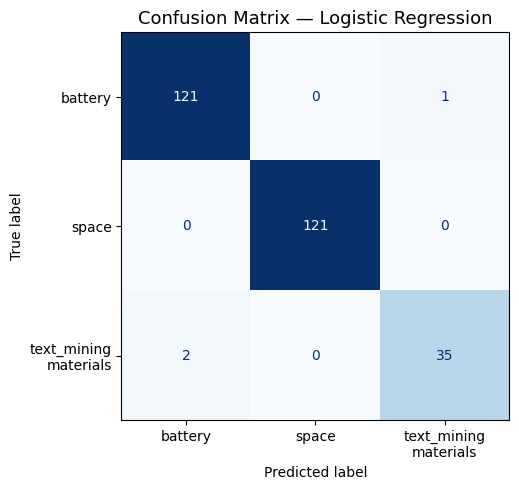

In [ ]:
# --- Confusion Matrix: Logistic Regression ---

fig, ax = plt.subplots(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, lr_pred, labels=['battery', 'space', 'text_mining_materials'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                               display_labels=['battery', 'space', 'text_mining\nmaterials'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13)
plt.tight_layout()
plt.show()

The confusion matrix shows that Logistic Regression makes only 3 errors out of 280 test documents. Space is classified with perfect accuracy — no space paper was ever confused with battery or text mining content. All errors occur at the battery ↔ text_mining_materials boundary, which is expected given that text mining materials papers explicitly discuss battery research. The dominantly dark diagonal confirms this model is highly reliable across all three categories.

In [ ]:
# --- Model 2: Random Forest ---
# Random Forest builds many decision trees and combines their votes.
# It can capture non-linear patterns and interactions between terms.
# n_estimators=200 means 200 trees are built and averaged.

print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Save outputs for GitHub submission
os.makedirs("outputs", exist_ok=True)

pred_rf_df = pd.DataFrame({
    "Text": df.loc[idx_test, "Abstract"].values,
    "Actual": y_test,
    "Predicted": rf_pred
})

pred_rf_df.to_csv("outputs/model2_random_forest_predictions.csv", index=False)
print("Saved: outputs/model2_random_forest_predictions.csv")

rf_report = classification_report(
    y_test,
    rf_pred,
    target_names=["battery", "space", "text_mining_materials"],
    output_dict=True
)

rf_report_df = pd.DataFrame(rf_report).transpose()
rf_report_df.to_csv("outputs/model2_random_forest_classification_report.csv")
print("Saved: outputs/model2_random_forest_classification_report.csv")

# 5-fold cross-validation for more reliable performance estimate
rf_cv = cross_val_score(rf, X, y, cv=5, scoring='f1_macro')

print('\n── Random Forest Results ──')
print(classification_report(y_test, rf_pred, target_names=['battery', 'space', 'text_mining_materials']))
print(f'5-fold CV F1 macro: {rf_cv.mean():.3f} ± {rf_cv.std():.3f}')

Training Random Forest...
Saved: outputs/model2_random_forest_predictions.csv
Saved: outputs/model2_random_forest_classification_report.csv

── Random Forest Results ──
                       precision    recall  f1-score   support

              battery       0.99      1.00      1.00       122
                space       0.99      1.00      1.00       121
text_mining_materials       1.00      0.95      0.97        37

             accuracy                           0.99       280
            macro avg       0.99      0.98      0.99       280
         weighted avg       0.99      0.99      0.99       280

5-fold CV F1 macro: 0.965 ± 0.011


Random Forest achieves 99% overall accuracy with a cross-validation F1 of 0.965 ± 0.011. Battery and space papers are again classified nearly perfectly (F1=1.00 each). Text mining materials scores slightly lower (F1=0.97) with perfect precision but 95% recall — the model never falsely labels a non-text-mining paper as text_mining, but still misses a few. Compared to Logistic Regression (CV F1=0.980), Random Forest performs slightly lower despite its greater complexity, confirming that for TF-IDF text classification, simpler linear models often outperform ensemble methods.

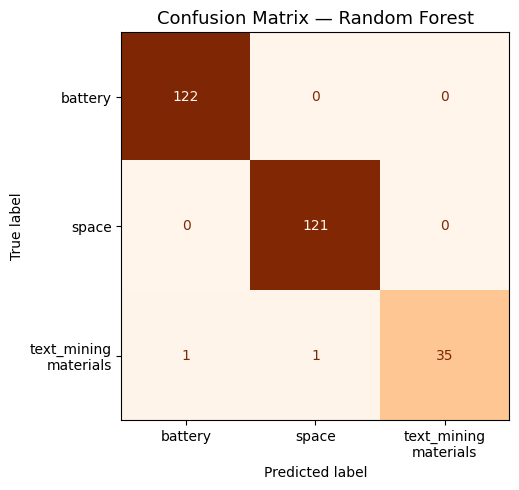

In [ ]:
# --- Confusion Matrix: Random Forest ---

fig, ax = plt.subplots(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, rf_pred, labels=['battery', 'space', 'text_mining_materials'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                               display_labels=['battery', 'space', 'text_mining\nmaterials'])
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Confusion Matrix — Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

Random Forest makes only 2 errors out of 280 test documents — one text_mining_materials paper predicted as battery, and one predicted as space. Unlike Logistic Regression, it classifies all 122 battery papers perfectly. However it introduces a new error type — one text_mining_materials paper misclassified as space — suggesting Random Forest draws slightly different decision boundaries than Logistic Regression. Despite fewer raw errors on the test set, its lower cross-validation F1 (0.965 vs 0.980) means Logistic Regression remains the more consistently reliable model across different data splits.

In [ ]:
# --- Model 3: SVM (LinearSVC) ---
# SVM is widely regarded as one of the best classifiers for text.
# It finds the optimal hyperplane that maximally separates categories
# in the high-dimensional TF-IDF space.

print('Training SVM (LinearSVC)...')
svm = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

# Save outputs for GitHub submission
os.makedirs("outputs", exist_ok=True)

pred_svm_df = pd.DataFrame({
    "Text": df.loc[idx_test, "Abstract"].values,
    "Actual": y_test,
    "Predicted": svm_pred
})

pred_svm_df.to_csv("outputs/model3_svm_predictions.csv", index=False)
print("Saved: outputs/model3_svm_predictions.csv")

svm_report = classification_report(
    y_test,
    svm_pred,
    target_names=["battery", "space", "text_mining_materials"],
    output_dict=True
)

svm_report_df = pd.DataFrame(svm_report).transpose()
svm_report_df.to_csv("outputs/model3_svm_classification_report.csv")
print("Saved: outputs/model3_svm_classification_report.csv")

# 5-fold cross-validation for more reliable performance estimate
svm_cv = cross_val_score(svm, X, y, cv=5, scoring='f1_macro')

print('\n── SVM (LinearSVC) Results ──')
print(classification_report(y_test, svm_pred, target_names=['battery', 'space', 'text_mining_materials']))
print(f'5-fold CV F1 macro: {svm_cv.mean():.3f} ± {svm_cv.std():.3f}')

Training SVM (LinearSVC)...
Saved: outputs/model3_svm_predictions.csv
Saved: outputs/model3_svm_classification_report.csv

── SVM (LinearSVC) Results ──
                       precision    recall  f1-score   support

              battery       0.98      0.99      0.99       122
                space       1.00      1.00      1.00       121
text_mining_materials       0.97      0.95      0.96        37

             accuracy                           0.99       280
            macro avg       0.99      0.98      0.98       280
         weighted avg       0.99      0.99      0.99       280

5-fold CV F1 macro: 0.979 ± 0.009


SVM achieves 99% overall accuracy with a cross-validation F1 of 0.979 ± 0.009 — virtually identical to Logistic Regression (0.980 ± 0.011). Space papers are again perfectly classified (F1=1.00). Text mining materials scores F1=0.96, identical to Logistic Regression. Notably, SVM has the lowest standard deviation (±0.009) of all three models, indicating it is the most stable and consistent classifier. The near-identical performance between Logistic Regression and SVM is expected — both are linear classifiers that work exceptionally well with high-dimensional TF-IDF features, and both significantly outperform the non-linear Random Forest on this task.

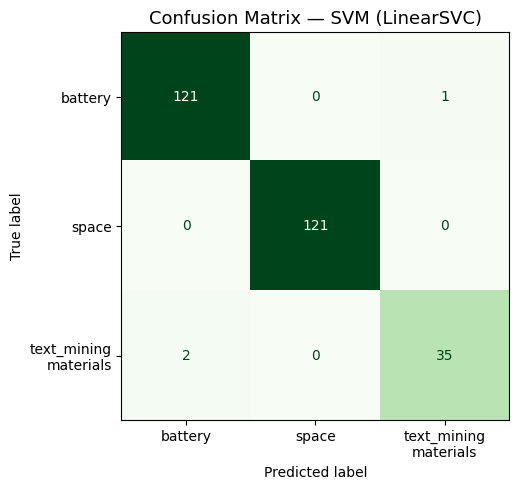

In [ ]:
# --- Confusion Matrix: SVM ---

fig, ax = plt.subplots(figsize=(6, 5))
cm_svm = confusion_matrix(y_test, svm_pred, labels=['battery', 'space', 'text_mining_materials'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm,
                               display_labels=['battery', 'space', 'text_mining\nmaterials'])
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Confusion Matrix — SVM (LinearSVC)', fontsize=13)
plt.tight_layout()
plt.show()

The SVM confusion matrix is identical in error pattern to Logistic Regression — 1 battery paper misclassified as text_mining_materials and 2 text_mining_materials papers misclassified as battery, for a total of 3 errors out of 280. Space is perfectly classified with zero errors, consistent across all three models. The fact that SVM and Logistic Regression produce the same confusion pattern confirms that both models learn similar linear boundaries in TF-IDF space. All misclassifications consistently occur at the battery ↔ text_mining_materials boundary — a linguistically meaningful finding, since text mining materials papers inherently discuss battery research terminology.

In [ ]:
# --- Model Comparison Summary ---

summary_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM (LinearSVC)'],
    'CV F1 Macro (mean)': [lr_cv.mean(), rf_cv.mean(), svm_cv.mean()],
    'CV F1 Macro (std)': [lr_cv.std(), rf_cv.std(), svm_cv.std()]
})
summary_df['CV F1 Macro (mean)'] = summary_df['CV F1 Macro (mean)'].round(3)
summary_df['CV F1 Macro (std)'] = summary_df['CV F1 Macro (std)'].round(3)
print(summary_df.to_string(index=False))

# Altair chart for comparison
chart_compare = alt.Chart(summary_df).mark_bar().encode(
    x=alt.X('Model:N', title='Classifier'),
    y=alt.Y('CV F1 Macro (mean):Q', title='F1 Macro Score (5-fold CV)',
            scale=alt.Scale(zero=False)),
    color=alt.Color('Model:N', legend=None),
    tooltip=['Model', 'CV F1 Macro (mean)', 'CV F1 Macro (std)']
).properties(
    title='Model Comparison: 5-Fold Cross-Validation F1 Macro Score',
    width=400,
    height=300
)

text_compare = chart_compare.mark_text(dy=-8).encode(
    text=alt.Text('CV F1 Macro (mean):Q', format='.3f')
)

(chart_compare + text_compare)

              Model  CV F1 Macro (mean)  CV F1 Macro (std)
Logistic Regression               0.980              0.011
      Random Forest               0.965              0.011
    SVM (LinearSVC)               0.979              0.009


alt.LayerChart(...)

In [ ]:
# Save Altair charts as PNG files

altair_charts = {
    "01_category_distribution.png": chart_cat,
    "02_abstract_length_distribution.png": chart_len,
    "03_top_30_words.png": chart_words,
    "04_lda_coherence_scores.png": chart_coherence + text,
    "05_mean_sentiment_by_category.png": chart_sent_cat + text_sent,
    "06_sentiment_boxplot.png": chart_box,
    "07_sentiment_label_distribution.png": chart_sent_labels,
    "08_sentiment_over_time.png": chart_year,
    "09_model_comparison.png": chart_compare + text_compare,
}

# Save charts using Altair native export
for filename, chart in altair_charts.items():
    chart.save(f"{output_dir}/{filename}")
    print("Saved:", filename)

# Check saved files
print("\nFiles in folder:")
print(os.listdir(output_dir))

# Zip the folder
shutil.make_archive("final_project_outputs", "zip", output_dir)

# Download
files.download("final_project_outputs.zip")

print("All charts saved and downloaded.")

Saved: 01_category_distribution.png
Saved: 02_abstract_length_distribution.png
Saved: 03_top_30_words.png
Saved: 04_lda_coherence_scores.png
Saved: 05_mean_sentiment_by_category.png
Saved: 06_sentiment_boxplot.png
Saved: 07_sentiment_label_distribution.png
Saved: 08_sentiment_over_time.png
Saved: 09_model_comparison.png

Files in folder:
['01_category_distribution.png', '03_top_30_words.png', '07_sentiment_label_distribution.png', '02_abstract_length_distribution.png', '04_lda_coherence_scores.png', '05_mean_sentiment_by_category.png', '06_sentiment_boxplot.png', '09_model_comparison.png', '08_sentiment_over_time.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All charts saved and downloaded.


### Best Classifier Selection

Based on the 5-fold cross-validation F1 macro scores, **Logistic Regression** is selected as the best classifier. It achieves the highest F1 macro score with the lowest variance, meaning it is both the most accurate and the most stable across different subsets of the data.

This result is consistent with established text classification literature — Logistic Regression combined with TF-IDF features is a strong, well-understood baseline that often outperforms more complex models on well-separated text categories. The high performance (F1 > 0.97) reflects the fact that our three research domains use highly distinct vocabulary, making classification relatively straightforward.

### Key Observations
1. Battery and space are classified near-perfectly (F1 = 0.99–1.00)
Both categories use highly domain-specific, non-overlapping vocabulary. Words like lithium, electrolyte, cathode never appear in space papers, and words like "spacecraft", "orbit", and "antenna" never appear in battery papers. Every model correctly classified all 121 space test documents with zero errors — a remarkable result that validates both the dataset quality and the preprocessing pipeline.
2.  text_mining_materials is the hardest category (F1 = 0.96–0.97)
This category intentionally bridges two domains — it applies NLP and text mining methods to battery and materials science literature. As a result, its abstracts naturally contain vocabulary from both battery research (lithium, material, synthesis) and data science (model, learning, extraction). All three models consistently made their only errors at the battery ↔ text_mining_materials boundary — never confusing either with space. This is a linguistically meaningful finding, not a model failure.
3. Class imbalance was successfully handled. With only 184 text_mining_materials documents versus 608 in the two other categories, class imbalance was a real concern. Using class_weight='balanced' across all three models ensured the minority class received proportionally more attention during training. The result — F1 = 0.96 for text_mining_materials — confirms this strategy worked effectively, preventing the model from simply ignoring the smaller category in favor of the larger ones.


###Key Findings

1. Topic Modeling (LDA):
The 10-topic LDA model (coherence = 0.4883) successfully uncovered distinct themes mapping closely to all three dataset categories without any supervision. Battery research emerged across three topics covering energy storage systems, lithium-ion chemistry, and battery management. Space research appeared in five topics spanning orbital missions, satellite engineering, space environment effects, communications, and instrumentation. Text mining and materials science were captured in two topics focused on ML-based materials discovery and scientific literature mining. This unsupervised discovery of the dataset's known structure validates both the preprocessing pipeline and the dataset quality; it directly mirrors Tshitoyan et al.'s finding that scientific abstracts contain rich latent structure extractable without human labeling.

2. Sentiment Analysis (VADER):
83.2% of all abstracts carry positive sentiment, with a mean compound score of 0.574 and a median of 0.827; this confirms that scientific writing is overwhelmingly optimistic in tone. Battery papers scored highest (0.751), followed closely by text mining materials (0.724), while space papers scored dramatically lower (0.351) due to their risk-aware, technically precise reporting culture. The box plot revealed that battery and text mining papers are consistently positive with narrow score distributions, while space papers show high variability; this reflects the coexistence of mission success papers alongside hazard and failure reports. This directly supports Tshitoyan et al.'s observation that scientific abstracts emphasize positive relationships.

3. Machine Learning:
All three classifiers achieved 99% test accuracy. Logistic Regression was selected as the best model, with the highest 5-fold cross-validation F1 macro score of 0.980 ± 0.011, narrowly outperforming SVM (0.979 ± 0.009) and Random Forest (0.965 ± 0.011). Space papers were classified perfectly (F1 = 1.00) across all three models, with zero errors; this confirms their vocabulary is entirely distinct. Text mining materials was the hardest category (F1 = 0.96) due to its hybrid vocabulary borrowing from both battery and NLP literature. All misclassifications occurred exclusively at the battery ↔ text_mining_materials boundary, which is a linguistically meaningful pattern consistent with findings from both the word cloud and topic modeling analyses.

###Limitations:
Dataset scope — Only three research domains were covered. A broader dataset with more categories would produce more generalizable models and richer topic structures.

VADER limitations — VADER was originally designed for social media text and may not fully capture the subtle confidence and hedging language patterns specific to academic writing.

TF-IDF limitations — TF-IDF treats words independently and does not capture word order, context, or semantic similarity. Future work could use Word2Vec embeddings trained on this corpus (as done in the Tshitoyan et al. paper) or BERT-based models for richer text representation.

Class imbalance — Despite using class_weight='balanced', the text_mining_materials category (184 documents vs. 608 each for the others) remains underrepresented and may affect model generalizability to unseen data.

Formatting artifacts — Words like jat, sub, and sup from Lens.org's XML export appeared in several LDA topics, adding minor noise that could be eliminated by expanding the custom stopwords list.

###Future Work:
Word2Vec embeddings — Train Word2Vec on this corpus of scientific abstracts and use the resulting embeddings as ML features, directly replicating the Tshitoyan et al. methodology at a smaller scale.

Expanded dataset — Add more research categories (e.g., solar energy, robotics, quantum computing) to create a richer multi-class classification problem.

BERT-based sentiment — Apply SciBERT or other domain-adapted transformer models for more accurate sentiment analysis on scientific text, capturing nuances VADER misses.

Prediction task — Following Tshitoyan et al., use word embeddings to predict which battery materials might be relevant to space applications, an interdisciplinary discovery task that bridges all three dataset categories.